In [1]:
# imports
import numpy as np
import torch
from er_evaluation import pairwise_f, pairwise_precision, pairwise_recall
from torch.utils.data import DataLoader, ConcatDataset, random_split, TensorDataset, ChainDataset

from dataset_utils.Cresci17 import Cresci17, Cresci17SetTypes
from transformers import DistilBertTokenizer, AutoModel
import math
import re
import hdbscan
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score, accuracy_score, \
    f1_score, recall_score
from sklearn.preprocessing import RobustScaler
from hdbscan import approximate_predict
from sklearn.cluster import Birch
import joblib
from torch import nn
from pipeline_utils import create_profile_vector, create_tweet_vectors, train_classifier, test_classifier
from ClassificationHeads import BaselineClassificationHead

/home/max/anaconda3/envs/social-media-bot-detection/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# set training datasets
genuine_user = Cresci17(Cresci17SetTypes.GENUINE_USER, "train", 0.8, 0.1, root="./datasets")
social_spam1 = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_1, "train", 0.8, 0.1, root="./datasets")
fake_follower = Cresci17(Cresci17SetTypes.FAKE_FOLLOWER, "train", 0.8, 0.1, root="./datasets")

train_dataloader = DataLoader(ChainDataset([genuine_user, social_spam1, fake_follower]), batch_size=None,batch_sampler=None, pin_memory=True)

# set testing datasets
genuine_user = Cresci17(Cresci17SetTypes.GENUINE_USER, "test", 0.8, 0.1, root="./datasets")
social_spam1 = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_1, "test", 0.8, 0.1, root="./datasets")
fake_follower = Cresci17(Cresci17SetTypes.FAKE_FOLLOWER, "test", 0.8, 0.1, root="./datasets")

test_dataloader = DataLoader(ChainDataset([genuine_user, social_spam1, fake_follower]), batch_size=None,batch_sampler=None, pin_memory=True)

mapping = {
    "genuine_user": 0,
    "fake_followers": 1,
    "social_spambots_1": 2,
    "traditional_spambots_1": 3
}
#traditional_spam = Cresci17(root="./datasets", subset_type=Cresci17SetTypes.TRADITIONAL_SPAM_1)


In [3]:


# initiate models
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
dim_reducer = umap.UMAP(n_components=16, n_neighbors=20, min_dist=0.1, metric="cosine", target_metric="categorical", target_weight=0.25)
clusterer = Birch(threshold=3,n_clusters=None)#hdbscan.HDBSCAN(min_cluster_size=60, min_samples=20, prediction_data=True, cluster_selection_epsilon=0.5)
scaler = RobustScaler(with_centering=False)
classifier = BaselineClassificationHead(23,10).to(device)

# training loop
ground_truth_labels = []
profile_vectors = []
tweet_vectors = []
for i, sample in enumerate(train_dataloader):
    # get feature vectors
    profile_embed = create_profile_vector(sample.user_data)
    tweet_embeds = create_tweet_vectors(sample.tweet_data, tokenizer, model, max_tweets= 50, batch_size = 50)

    # pool tweet vectors
    tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)

    # append feature vectors and ground truth
    profile_vectors.append(profile_embed)
    tweet_vectors.append(tweet_vec)
    ground_truth_labels.append(mapping[sample.label])
    print(f"\rIteration: {i}", end="")

# reduce tweet vectors in dimensionality
reduced_tweet_vectors = dim_reducer.fit_transform(X=tweet_vectors, y=torch.tensor(ground_truth_labels))
reduced_tweet_vectors = np.nan_to_num(reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)

# scale profile vectors
scaled_profile_vectors = scaler.fit_transform(profile_vectors)

# combine feature vectors
embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(reduced_tweet_vectors, scaled_profile_vectors)]

# perform clustering
cluster_labels = clusterer.fit_predict(embedding_features)

# perform classification training

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)

ground_truths, predictions = train_classifier(classifier, criterion, optimizer, embedding_features, ground_truth_labels)
train_embeds = embedding_features
train_ground_truth = ground_truth_labels
print("accuracy: ", accuracy_score(ground_truths, predictions))
print("recall: ", recall_score(ground_truths, predictions, average="macro"))
print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
print(confusion_matrix(ground_truths, predictions))

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8485.51it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 4983Epoch [1/15] - Loss: 0.6324
Epoch [2/15] - Loss: 0.1393
Epoch [3/15] - Loss: 0.0992
Epoch [4/15] - Loss: 0.0919
Epoch [5/15] - Loss: 0.0822
Epoch [6/15] - Loss: 0.0686
Epoch [7/15] - Loss: 0.0710
Epoch [8/15] - Loss: 0.0700
Epoch [9/15] - Loss: 0.0681
Epoch [10/15] - Loss: 0.0734
Epoch [11/15] - Loss: 0.0706
Epoch [12/15] - Loss: 0.0580
Epoch [13/15] - Loss: 0.0631
Epoch [14/15] - Loss: 0.0679
Epoch [15/15] - Loss: 0.0630
accuracy:  0.9813402889245586
recall:  0.943031176494035
f1 score:  0.9549763141203959
[[2523   37    3]
 [  42 2305    1]
 [   4    6   63]]


/home/max/anaconda3/envs/social-media-bot-detection/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


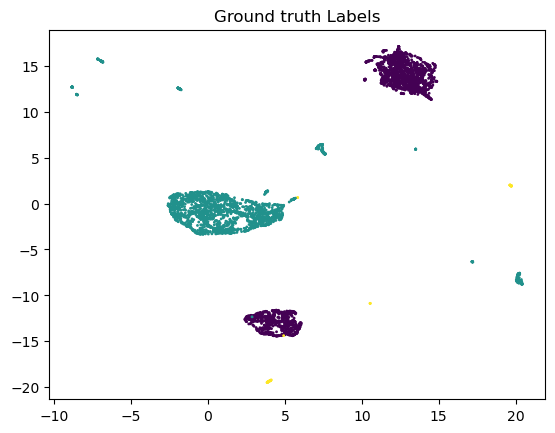

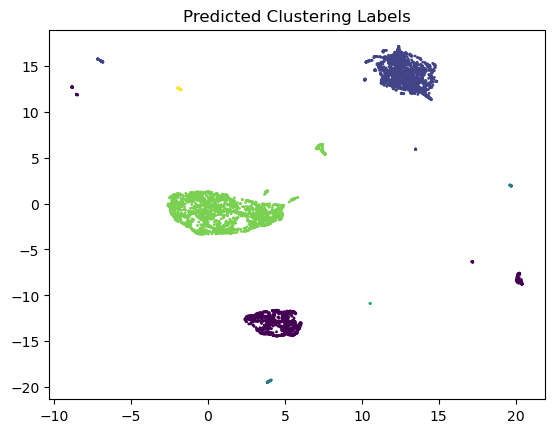

4984
Predicted Labels:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
[[ 798 1761    0    0    4    0]
 [ 174   71    0    0 2055   48]
 [   1    0   66    3    3    0]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]]
Precision:  0.9347273797806155
Recall:  0.6619517715741998
F1 score 0.7750391735993681
Adjusted Rand Index:  0.6229357533113574
Normalized Mutual Info:  0.620412831774548


In [4]:
# evaluation

# remap feature vectors to 2D representation for plotting
plot_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, target_metric="categorical", target_weight=0.5)
coords = plot_reducer.fit_transform(X=embedding_features, y=torch.tensor(ground_truth_labels))
# plot ground truth
plt.title("Ground truth Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=ground_truth_labels)
plt.show()
# plot predictions labels
plt.title("Predicted Clustering Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=cluster_labels)
plt.show()

# calculate metrics
print(len(ground_truth_labels))
print("Predicted Labels: ", list(set(cluster_labels)))
print(confusion_matrix(ground_truth_labels, cluster_labels,labels=list(set(cluster_labels))))
print("Precision: ", pairwise_precision(cluster_labels, ground_truth_labels))
print("Recall: ", pairwise_recall(cluster_labels, ground_truth_labels))
print("F1 score", pairwise_f(cluster_labels, ground_truth_labels))
print("Adjusted Rand Index: ", adjusted_rand_score(ground_truth_labels, cluster_labels))
print("Normalized Mutual Info: ", normalized_mutual_info_score(ground_truth_labels, cluster_labels))

In [5]:
# save model parameters
models_to_save = {
    "reducer": dim_reducer,
    "scaler": scaler,
    "clusterer": clusterer
}
joblib.dump(models_to_save, "bot_detection_models.joblib")

['bot_detection_models.joblib']

In [6]:
# load existing model parameters
loaded_models = joblib.load("bot_detection_models.joblib")
dim_reducer = loaded_models["reducer"]
scaler = loaded_models["scaler"]
clusterer = loaded_models["clusterer"]

In [7]:
# testing loop

ground_truth_labels = []
profile_vectors = []
tweet_vectors = []
for i, sample in enumerate(test_dataloader):
    # get feature vectors
    profile_embed = create_profile_vector(sample.user_data)
    tweet_embeds = create_tweet_vectors(sample.tweet_data, tokenizer, model, max_tweets= 50, batch_size = 50)

    # pool tweet vectors
    tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)#torch.max(tweet_embeds, dim=0).values

    # append feature vectors and ground truth
    profile_vectors.append(profile_embed)
    tweet_vectors.append(tweet_vec)
    ground_truth_labels.append(mapping[sample.label])
    print(f"\rIteration: {i}", end="")

# reduce tweet vectors in dimensionality
reduced_tweet_vectors = dim_reducer.transform(tweet_vectors)
reduced_tweet_vectors = np.nan_to_num(reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)

# scale profile vectors
scaled_profile_vectors = scaler.transform(profile_vectors)

# combine feature vectors
embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(reduced_tweet_vectors, scaled_profile_vectors)]

# perform clustering
#cluster_labels, _ = hdbscan.approximate_predict(clusterer= clusterer,points_to_predict= embedding_features)
cluster_labels = clusterer.fit_predict(embedding_features)
# test classifier
ground_truths, predictions = test_classifier(classifier, embedding_features, ground_truth_labels)
test_embeds = embedding_features
test_ground_truth = ground_truth_labels
print("accuracy: ", accuracy_score(ground_truths, predictions))
print("recall: ", recall_score(ground_truths, predictions, average="macro"))
print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
print(confusion_matrix(ground_truths, predictions))

Iteration: 616accuracy:  0.7601296596434359
recall:  0.7475951032796884
f1 score:  0.7755590587960531
[[187 136   0]
 [  8 273   0]
 [  1   3   9]]


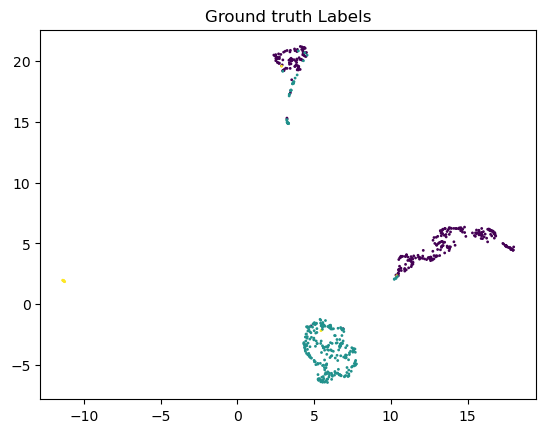

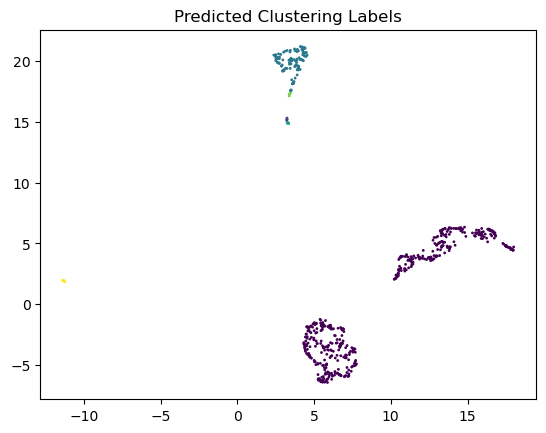

617
Predicted Labels:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
[[220   2  98   1   2   0]
 [245   2  20  11   3   0]
 [  3   0   1   0   0   9]
 [  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0   0   0   0   0]]
Precision:  0.5069964008692889
Recall:  0.6456175277015128
F1 score 0.5679712083449611
Adjusted Rand Index:  0.06298863770005596
Normalized Mutual Info:  0.1527392478203566


In [8]:
# evaluation

# remap feature vectors to 2D representation for plotting
plot_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
coords = plot_reducer.fit_transform(embedding_features)
# plot ground truth
plt.title("Ground truth Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=ground_truth_labels)
plt.show()
# plot predictions labels
plt.title("Predicted Clustering Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=cluster_labels)
plt.show()

# calculate metrics
print(len(ground_truth_labels))
print("Predicted Labels: ", list(set(cluster_labels)))
print(confusion_matrix(ground_truth_labels, cluster_labels,labels=list(set(cluster_labels))))
print("Precision: ", pairwise_precision(cluster_labels, ground_truth_labels))
print("Recall: ", pairwise_recall(cluster_labels, ground_truth_labels))
print("F1 score", pairwise_f(cluster_labels, ground_truth_labels))
print("Adjusted Rand Index: ", adjusted_rand_score(ground_truth_labels, cluster_labels))
print("Normalized Mutual Info: ", normalized_mutual_info_score(ground_truth_labels, cluster_labels))

In [9]:
# simple demonstration of the PNN classifier
%load_ext autoreload
%autoreload 2
device = "cuda"
from ClassificationHeads import ProgressiveNeuralNetworkClassifier
# map ground_truth labels
label_map = {
    1: 0,
    2: 1,
    3: 2,
    6: 3,
}

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)
classifier = ProgressiveNeuralNetworkClassifier(23,3).to(device)

# train on first half of datasets
ground, predict = train_classifier(classifier, criterion, optimizer,train_embeds, train_ground_truth, epochs = 30)
print("accuracy: ", accuracy_score(ground, predict))
print("recall: ", recall_score(ground, predict, average="macro"))
print("f1 score: ", f1_score(ground, predict, average="macro"))
print(confusion_matrix(ground, predict))

# expand classifier
before_w = classifier.classificationLayers[0].weight.detach().clone()
parameters = classifier.expand_classifier(1)
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)

# train on second half of set
ground, predict = train_classifier(classifier, criterion, optimizer,test_embeds, test_ground_truth)
print("accuracy: ", accuracy_score(ground, predict))
print("recall: ", recall_score(ground, predict, average="macro"))
print("f1 score: ", f1_score(ground, predict, average="macro"))
print(confusion_matrix(ground, predict))

print("is it the same: ", before_w == classifier.classificationLayers[0].weight)

ground, predict = test_classifier(classifier,train_embeds, train_ground_truth)
print("accuracy: ", accuracy_score(ground, predict))
print("recall: ", recall_score(ground, predict, average="macro"))
print("f1 score: ", f1_score(ground, predict, average="macro"))
print(confusion_matrix(ground, predict))


Epoch [1/30] - Loss: 4.8163
Epoch [2/30] - Loss: 4.8564
Epoch [3/30] - Loss: 4.8446
Epoch [4/30] - Loss: 4.8382
Epoch [5/30] - Loss: 4.8092
Epoch [6/30] - Loss: 4.8608
Epoch [7/30] - Loss: 4.8720
Epoch [8/30] - Loss: 4.8439
Epoch [9/30] - Loss: 4.8358
Epoch [10/30] - Loss: 4.8268
Epoch [11/30] - Loss: 4.8461
Epoch [12/30] - Loss: 4.8338
Epoch [13/30] - Loss: 4.8595
Epoch [14/30] - Loss: 4.8178
Epoch [15/30] - Loss: 4.8076
Epoch [16/30] - Loss: 4.8005
Epoch [17/30] - Loss: 4.8112
Epoch [18/30] - Loss: 4.8117
Epoch [19/30] - Loss: 4.8407
Epoch [20/30] - Loss: 4.8389
Epoch [21/30] - Loss: 4.8263
Epoch [22/30] - Loss: 4.8252
Epoch [23/30] - Loss: 4.8267
Epoch [24/30] - Loss: 4.7816
Epoch [25/30] - Loss: 4.8163
Epoch [26/30] - Loss: 4.8763
Epoch [27/30] - Loss: 4.8491
Epoch [28/30] - Loss: 4.8082
Epoch [29/30] - Loss: 4.8412
Epoch [30/30] - Loss: 4.8335
accuracy:  0.059189406099518456
recall:  0.10378332079074136
f1 score:  0.07214569219601856
[[   3   33 2527]
 [ 277  278 1793]
 [  45   14